# EDA on CIC-IDS 2018 Dataset
Prepared strictly per user instructions: fix numeric feature selection, handle plotting, and add comments.

In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df1 = pd.read_csv('../../data/raw/03-02-2018.csv', low_memory=False)
df2 = pd.read_csv('../../data/raw/02-16-2018.csv', low_memory=False)

In [3]:
# Sample data
df1_sampled = df1.sample(n=100000, random_state=42)
df2_sampled = df2.sample(n=100000, random_state=42)
df = pd.concat([df1_sampled, df2_sampled], ignore_index=True)

In [4]:
# Check dataset structure
print('Shape:', df.shape)
print('Number of columns:', len(df.columns))
print('Columns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
display(df.head())

Shape: (200000, 80)
Number of columns: 80
Columns: ['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b 

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,17,02/03/2018 08:56:19,227,1,1,37,53.0,37,37,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,443,6,02/03/2018 04:07:21,521,3,0,77,0.0,46,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,50434,6,02/03/2018 10:33:31,27,1,1,0,0.0,0,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,53,17,02/03/2018 04:58:37,250,1,1,40,56.0,40,40,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,53959,6,02/03/2018 11:26:31,86135655,2,0,0,0.0,0,0,...,20,0.0,0.0,0.0,0.0,86100000.0,0.0,86100000.0,86100000.0,Benign


In [5]:
# Clean columns
cols_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
df.drop(columns=cols_to_drop, errors='ignore', inplace=True)
feature_cols = df.columns.drop(['Label'], errors='ignore')
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [6]:
# Create binary labels
df['Label'] = df['Label'].astype(str).str.lower().str.strip()
df['BinaryLabel'] = (df['Label'] != 'benign').astype(int)
df['AttackType'] = df['Label']

In [7]:
# Validate labels
print("Label counts:")
print(df['Label'].value_counts())
print("\nBinaryLabel counts:")
print(df['BinaryLabel'].value_counts())

Label counts:
Label
benign                      114681
dos attacks-hulk             43989
bot                          27573
dos attacks-slowhttptest     13364
Name: count, dtype: int64

BinaryLabel counts:
BinaryLabel
0    114681
1     84926
Name: count, dtype: int64


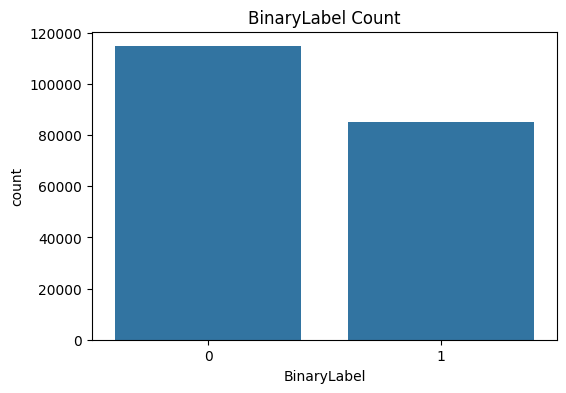

In [8]:
# Plot label distribution
output_dir = '../../outputs/plots/eda'
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(6, 4))
sns.countplot(x='BinaryLabel', data=df)
plt.title('BinaryLabel Count')
plt.savefig(f'{output_dir}/label_distribution.png')
plt.show()

In [9]:
# Select numerical features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'BinaryLabel' in num_cols:
    num_cols.remove('BinaryLabel')

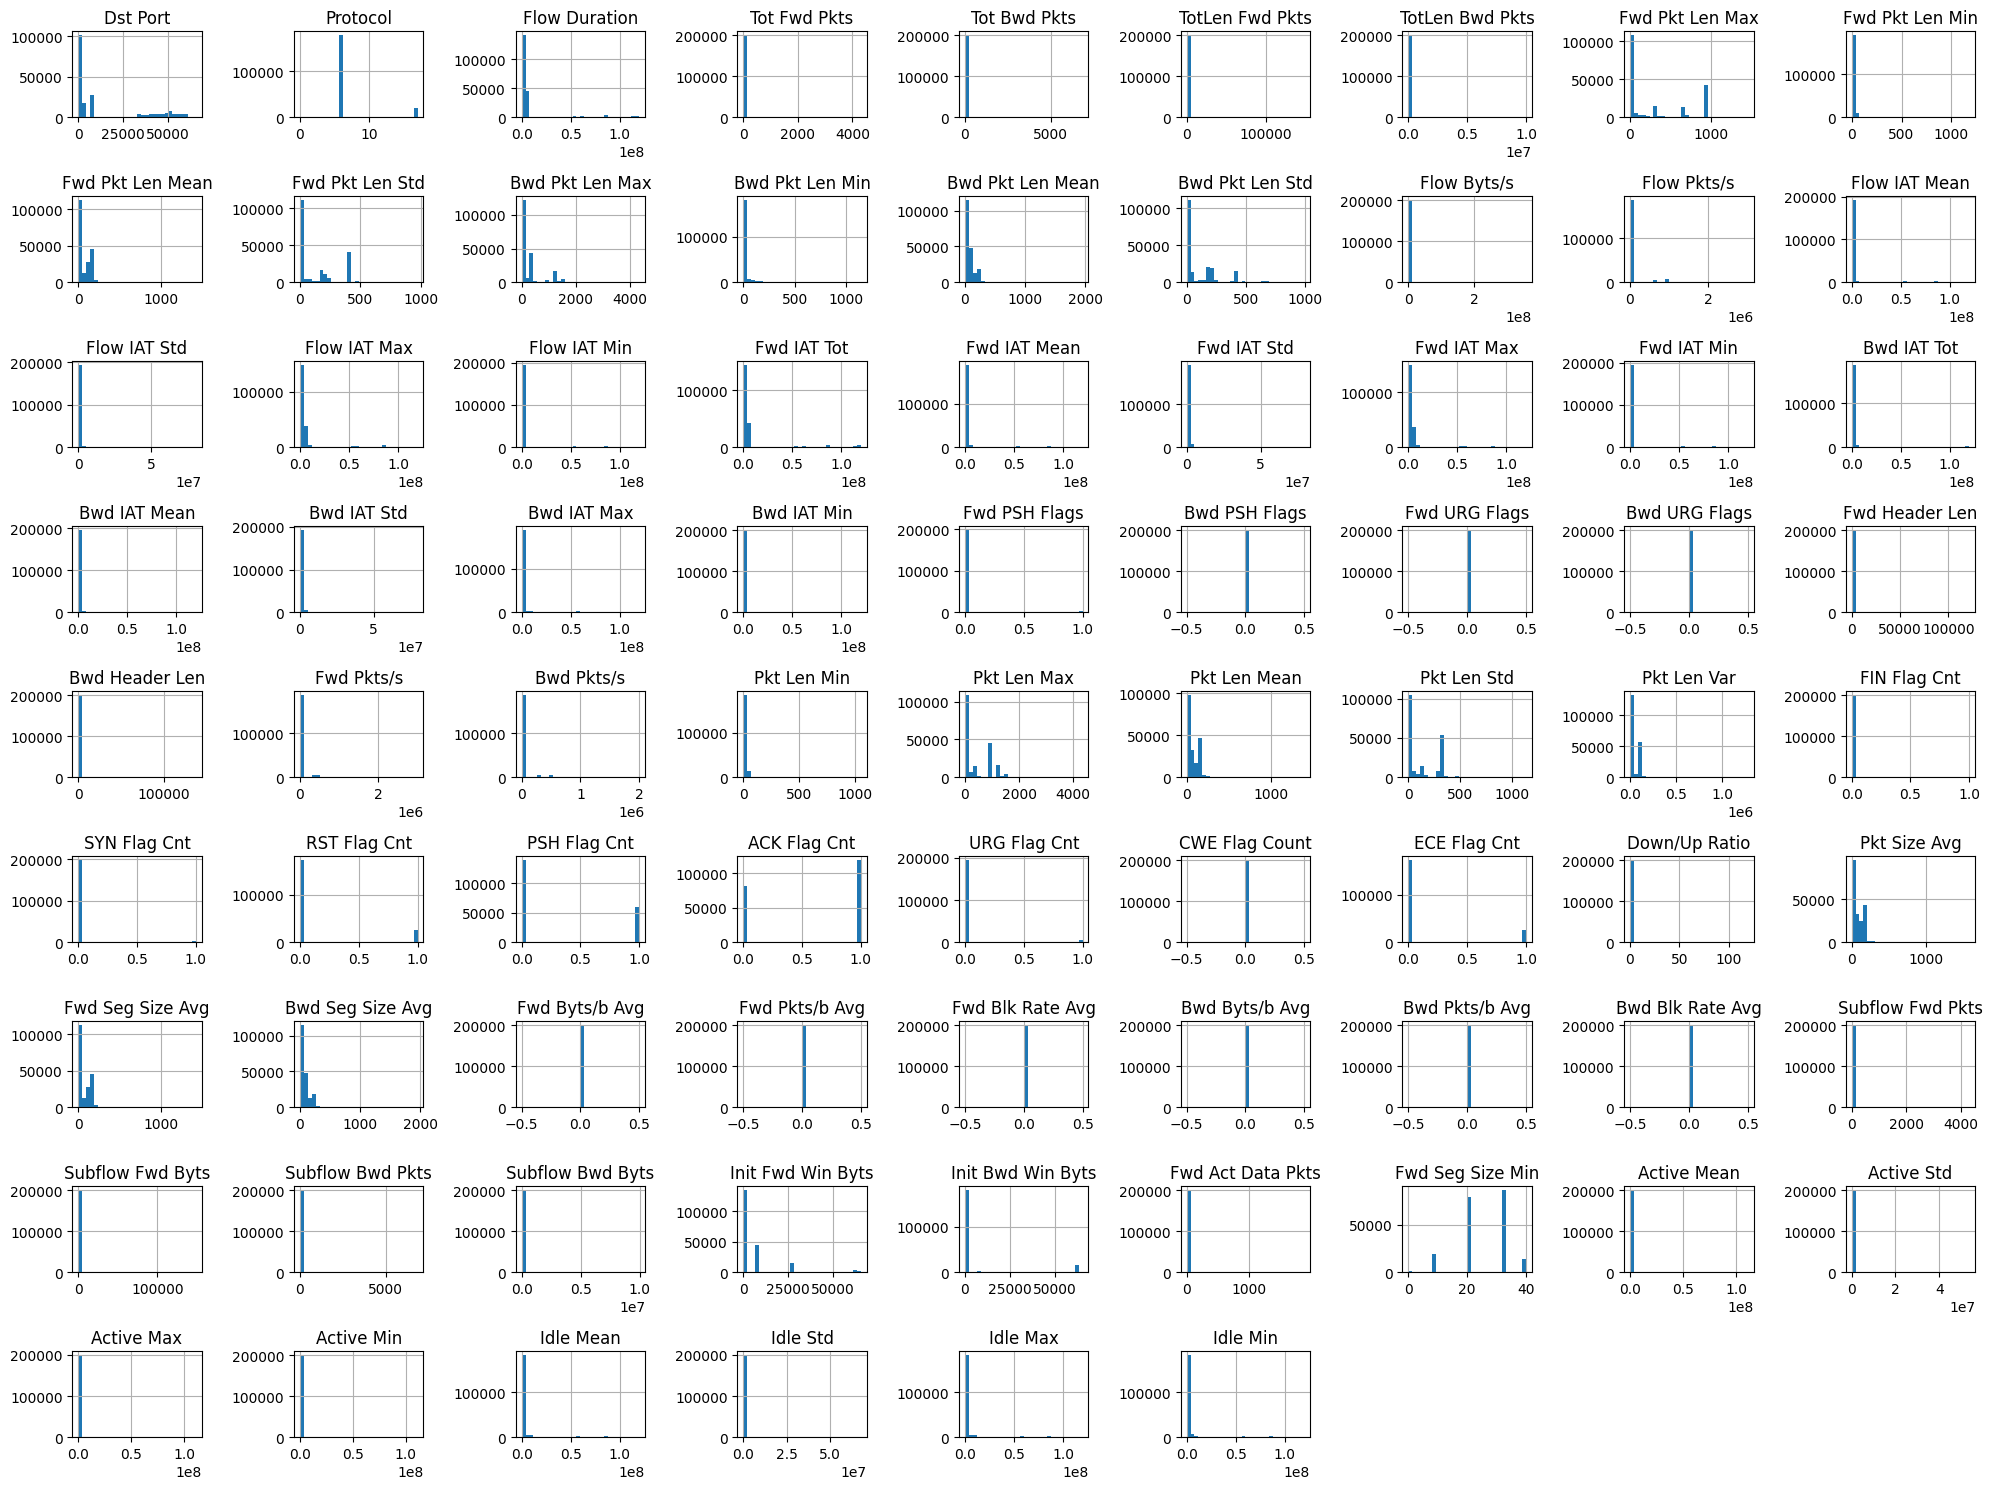

In [10]:
# Plot feature distributions
df[num_cols].hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.savefig(f'{output_dir}/feature_histograms.png')
plt.show()

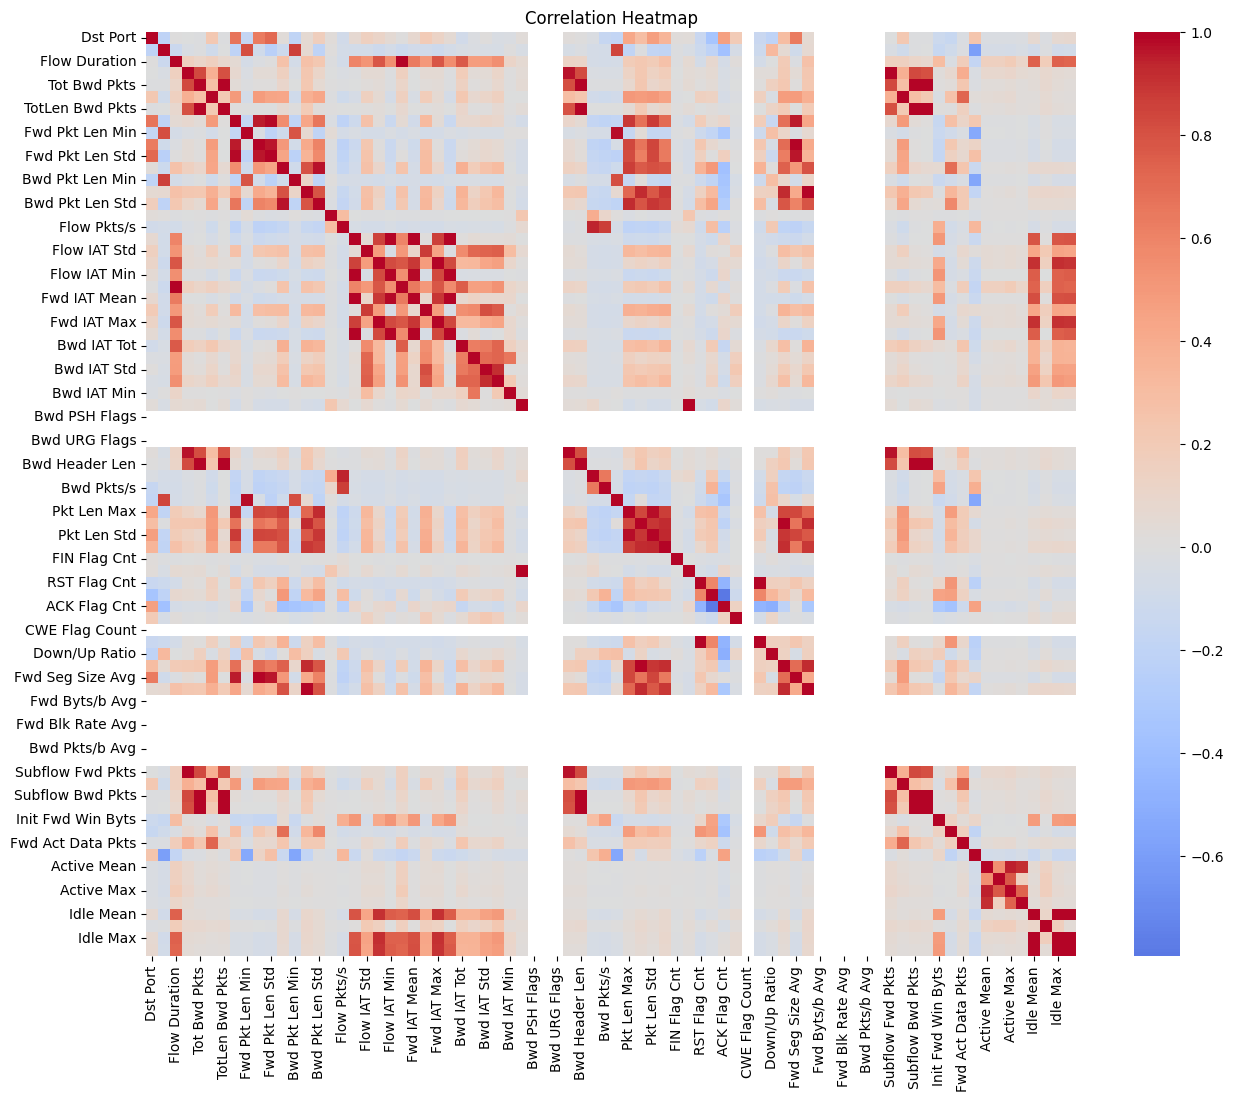

In [11]:
# Compute correlation matrix
plt.figure(figsize=(15, 12))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig(f'{output_dir}/correlation_heatmap.png')
plt.show()

In [12]:
# Groupby mean table
agg = df.groupby('BinaryLabel').mean(numeric_only=True)
display(agg)

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
BinaryLabel,,,,,,,,,,,,,,,,,,,,,
0,22540.512012,7.785178,1.189370e+07,6.182001,6.156617,643.118110,3741.081801,489.141619,7.183553,104.428217,...,2.056836,22.237127,105909.042202,53840.937652,165750.047436,70814.363042,4.706764e+06,96267.459479,4.781473e+06,4.614011e+06
1,2868.077467,5.998163,1.822711e+05,2.142336,0.936262,62.132598,49.066328,61.464699,0.000000,20.060655,...,0.195865,29.340131,22.385465,0.864682,23.260521,21.685267,1.117848e+05,967.721044,1.124795e+05,1.111006e+05
